# FMA-small + MusicCaps — Quick EDA

Two separate datasets — different tracks, different sources, no shared
clips — so this notebook explores them independently rather than trying
to join them. Run in Colab/Kaggle with real internet access; CPU runtime
is fine for EDA.

**How they map onto the four tasks:**
- **Task 1 (BERT tags)** — MusicCaps captions / aspect-lists as the
  caption→tag proxy task the brief explicitly allows.
- **Task 2 (GNN structure)** — FMA-small audio + its 8 balanced genre
  labels, exactly the pairing the brief names for this task.
- **Task 3 (fusion)** — needs an audio graph *and* text for the same
  clip. FMA has no captions and MusicCaps captions don't describe FMA
  tracks, so pick one: (a) fuse FMA audio graphs with FMA's own
  genre/tag metadata as pseudo-text, or (b) build graphs from
  MusicCaps' own audio and fuse with its own captions. Decide after
  both EDAs below — there's a note at the end.
- **Task 4 (contrastive retrieval)** — MusicCaps only; it's the one
  dataset here with real audio-caption pairs to contrast against.


In [ ]:
!pip install -q librosa soundfile datasets yt-dlp matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.4 MB/s eta 0:00:00a 0:00:01


## Part A — FMA-small

### A.1 Download

In [ ]:
import os

BASE = "https://os.unil.cloud.switch.ch/fma"
os.makedirs("data/raw/fma", exist_ok=True)
%cd data/raw/fma

!wget -nc {BASE}/fma_metadata.zip
!wget -c {BASE}/fma_small.zip
!unzip -q -o fma_metadata.zip
!unzip -q -o fma_small.zip

%cd ../../..

/kaggle/working/data/raw/fma
--2026-09-06 11:55:06--  https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 358412441 (342M) [application/zip]
Saving to: ‘fma_metadata.zip’

fma_metadata.zip    100%[===================>] 341.81M  27.0MB/s    in 14s     

2026-09-06 11:55:20 (24.6 MB/s) - ‘fma_metadata.zip’ saved [358412441/358412441]

--2026-09-06 11:55:20--  https://os.unil.cloud.switch.ch/fma/fma_small.zip
Resolving os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)... 86.119.28.16, 2001:620:5ca1:201::214
Connecting to os.unil.cloud.switch.ch (os.unil.cloud.switch.ch)|86.119.28.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7679594875 (7.2G) [application/zip]
Saving to: ‘fma_small.zip’

fma_small.zip       100

### A.2 Load metadata

`tracks.csv` ships with a 3-level column header and needs a bit of
massaging (this mirrors the official loader in `mdeff/fma`'s `utils.py`
rather than reinventing it).

In [ ]:
import ast
import pandas as pd

def load_fma_tracks(filepath):
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])
    for col in [("track", "tags"), ("album", "tags"), ("artist", "tags"),
                ("track", "genres"), ("track", "genres_all")]:
        tracks[col] = tracks[col].map(ast.literal_eval)
    return tracks

tracks = load_fma_tracks("data/raw/fma/fma_metadata/tracks.csv")
small = tracks[tracks["set", "subset"] == "small"]
print(f"{len(small)} tracks in the small subset")
small["track", "genre_top"].value_counts()

8000 tracks in the small subset


(track, genre_top)
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [ ]:
print("Missing FMA genre labels:")
print(small["track", "genre_top"].isnull().sum())

Missing FMA genre labels:
0


### A.3 Genre balance

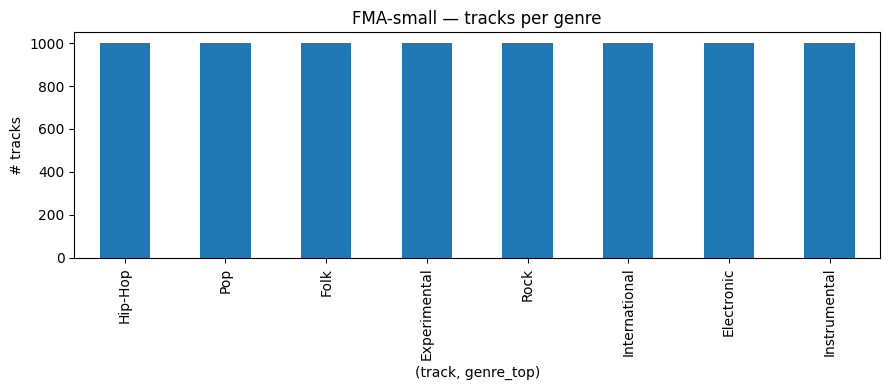

In [ ]:
import matplotlib.pyplot as plt

small["track", "genre_top"].value_counts().plot(kind="bar", figsize=(9, 4))
plt.title("FMA-small — tracks per genre")
plt.ylabel("# tracks")
plt.tight_layout()
plt.show()

### A.4 Audio sanity check

In [ ]:
def fma_audio_path(track_id, audio_dir="data/raw/fma/fma_small"):
    tid_str = f"{track_id:06d}"
    return f"{audio_dir}/{tid_str[:3]}/{tid_str}.mp3"

import glob
mp3_files = glob.glob("data/raw/fma/fma_small/*/*.mp3")
print(f"Found {len(mp3_files)} mp3 files on disk (expect ~8,000)")
print(mp3_files[:5])

Found 8000 mp3 files on disk (expect ~8,000)
['data/raw/fma/fma_small/054/054037.mp3', 'data/raw/fma/fma_small/054/054576.mp3', 'data/raw/fma/fma_small/054/054031.mp3', 'data/raw/fma/fma_small/054/054568.mp3', 'data/raw/fma/fma_small/054/054664.mp3']


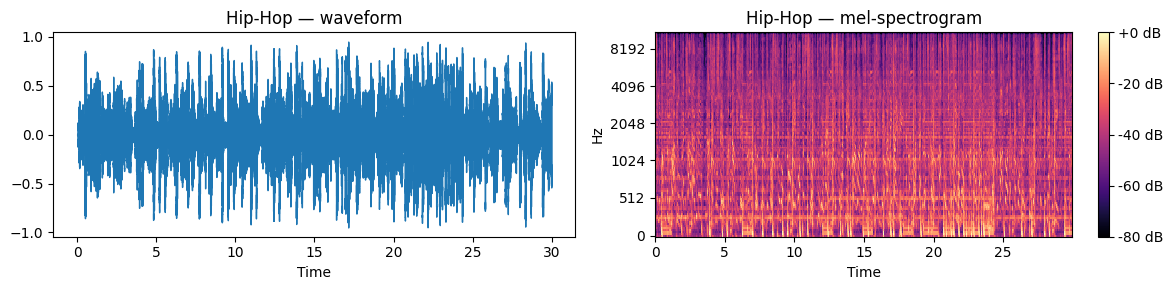

duration: 30.0s, sr: 22050


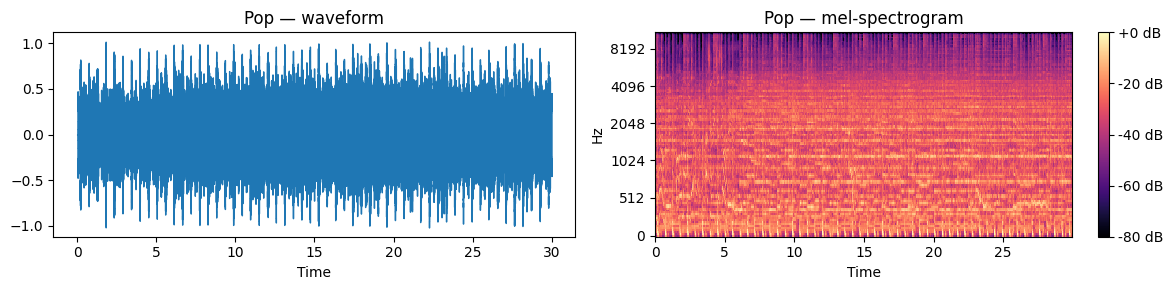

duration: 30.0s, sr: 22050


In [ ]:
import librosa, librosa.display
import numpy as np

def show_clip(mp3_path, title):
    y, sr = librosa.load(mp3_path, sr=22050, mono=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title(f"{title} — waveform")
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=ax[1])
    ax[1].set_title(f"{title} — mel-spectrogram")
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()
    print(f"duration: {len(y)/sr:.1f}s, sr: {sr}")

sample_genres = small["track", "genre_top"].dropna().unique()[:2]
for genre in sample_genres:
    tid = small[small["track", "genre_top"] == genre].index[0]
    path = fma_audio_path(tid)
    if os.path.exists(path):
        show_clip(path, genre)
    else:
        print(f"missing on disk: {path} (see the FMA errata link if this keeps happening)")

## Part B — MusicCaps

### B.1 Captions (fast — no audio yet)

Pulls just the caption table first, since that's small (~3 MB) and lets
you explore the text side immediately, before committing to the slow
YouTube download in B.3.

In [ ]:
from datasets import load_dataset

mc = load_dataset("google/MusicCaps")
print(mc)
split = "train" if "train" in mc else list(mc.keys())[0]
caps_df = mc[split].to_pandas()
print(caps_df.columns.tolist())
caps_df.head()

DatasetDict({
    train: Dataset({
        features: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
        num_rows: 5521
    })
})
['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [ ]:
print("Missing values in MusicCaps:")
print(caps_df.isnull().sum())

print("\nDuplicate YouTube IDs:")
print(caps_df["ytid"].duplicated().sum())

Missing values in MusicCaps:
ytid                        0
start_s                     0
end_s                       0
audioset_positive_labels    0
aspect_list                 0
caption                     0
author_id                   0
is_balanced_subset          0
is_audioset_eval            0
dtype: int64

Duplicate YouTube IDs:
0


### B.2 Caption + aspect-list exploration

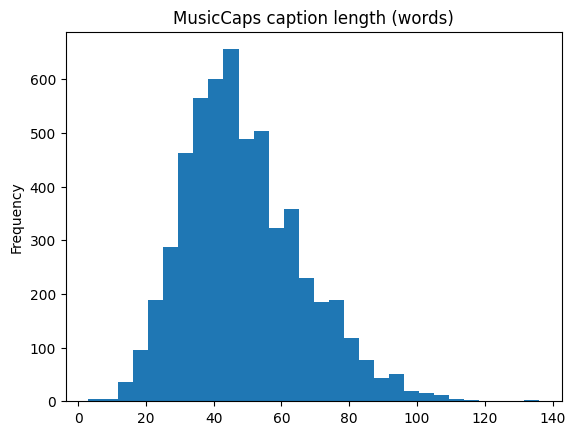

count    5521.000000
mean       48.968303
std        17.329780
min         3.000000
25%        37.000000
50%        46.000000
75%        60.000000
max       136.000000
Name: caption_len, dtype: float64
- Someone is playing a solo on a clean e-guitar along with a backing track that sounds like a slow soulful, sad ballad with strings,bass, acoustic drums and an e-guitar strumming single chords as a rhyt
- This song is a vocalisation by a female singer. The tempo is medium with an upbeat electronic guitar harmony, funky bass guitar, slick drumming and acoustic guitar accompaniment. The music is simple, 
- An acoustic drum is playing a groove with crash hits and a double-bass drum along with the e-bass and an e-guitar playing bass notes along with the complex kickdrum. A oriental sounding string and bra


In [ ]:
caps_df["caption_len"] = caps_df["caption"].str.split().str.len()
caps_df["caption_len"].plot(kind="hist", bins=30, title="MusicCaps caption length (words)")
plt.show()
print(caps_df["caption_len"].describe())

for c in caps_df["caption"].sample(3, random_state=0):
    print("-", c[:200])

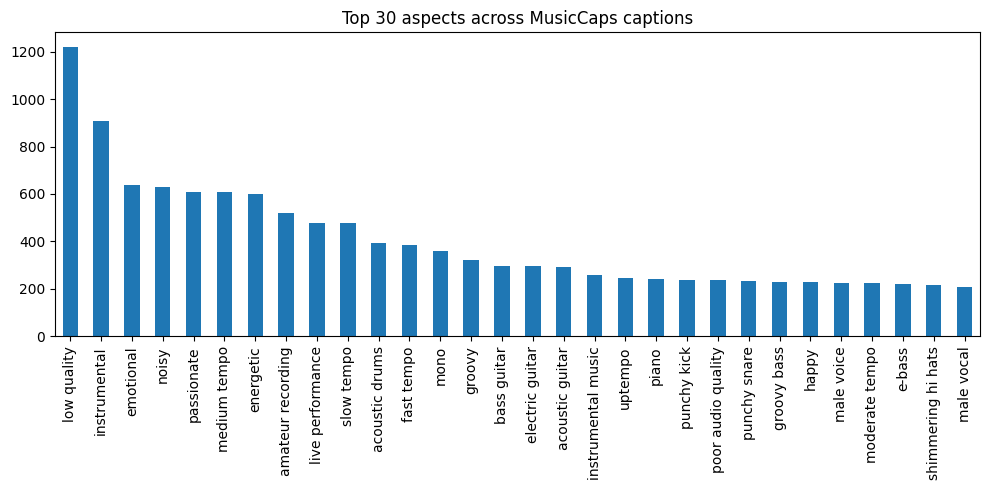

In [ ]:
# aspect_list contains multiple short descriptive labels for each MusicCaps example
# your closest thing to "tags" for the Task 1 proxy task.
from collections import Counter

aspects = Counter()
for row in caps_df["aspect_list"].dropna():
    for a in row.strip("[]").replace("'", "").split(","):
        aspects[a.strip()] += 1

pd.Series(dict(aspects.most_common(30))).plot(kind="bar", figsize=(10, 5))
plt.title("Top 30 aspects across MusicCaps captions")
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

all_aspects = []

for row in caps_df["aspect_list"].dropna():
    cleaned = row.strip("[]").replace("'", "")
    aspects = [a.strip() for a in cleaned.split(",") if a.strip()]
    all_aspects.extend(aspects)

aspect_counts = Counter(all_aspects)

print("Total unique aspects:", len(aspect_counts))
print("\nTop 30 most common aspects:")

for tag, count in aspect_counts.most_common(30):
    print(f"{tag}: {count}")

Total unique aspects: 13219

Top 30 most common aspects:
low quality: 1220
instrumental: 908
emotional: 636
noisy: 628
passionate: 610
medium tempo: 608
energetic: 599
amateur recording: 518
live performance: 477
slow tempo: 476
acoustic drums: 394
fast tempo: 383
mono: 358
groovy: 321
bass guitar: 297
electric guitar: 297
acoustic guitar: 292
instrumental music: 260
uptempo: 247
piano: 240
punchy kick: 239
poor audio quality: 236
punchy snare: 235
groovy bass: 229
happy: 228
male voice: 224
moderate tempo: 224
e-bass: 222
shimmering hi hats: 217
male vocal: 208


In [ ]:
top20 = [tag for tag, count in aspect_counts.most_common(20)]
top30 = [tag for tag, count in aspect_counts.most_common(30)]
top50 = [tag for tag, count in aspect_counts.most_common(50)]

def count_rows_with_any_tag(tag_list):
    count = 0

    for row in caps_df["aspect_list"].dropna():
        cleaned = row.strip("[]").replace("'", "")
        aspects = [a.strip() for a in cleaned.split(",") if a.strip()]

        if any(tag in aspects for tag in tag_list):
            count += 1

    return count

print("Rows covered by Top 20 tags:", count_rows_with_any_tag(top20))
print("Rows covered by Top 30 tags:", count_rows_with_any_tag(top30))
print("Rows covered by Top 50 tags:", count_rows_with_any_tag(top50))
print("Total MusicCaps rows:", len(caps_df))

Rows covered by Top 20 tags: 4517
Rows covered by Top 30 tags: 4786
Rows covered by Top 50 tags: 4995
Total MusicCaps rows: 5521


In [ ]:
print(caps_df.shape)
print(len(caps_df))

(5521, 10)
5521


In [ ]:
top50_counts = aspect_counts.most_common(50)

for i, (tag, count) in enumerate(top50_counts, start=1):
    print(f"{i:2d}. {tag}: {count}")

 1. low quality: 1220
 2. instrumental: 908
 3. emotional: 636
 4. noisy: 628
 5. passionate: 610
 6. medium tempo: 608
 7. energetic: 599
 8. amateur recording: 518
 9. live performance: 477
10. slow tempo: 476
11. acoustic drums: 394
12. fast tempo: 383
13. mono: 358
14. groovy: 321
15. bass guitar: 297
16. electric guitar: 297
17. acoustic guitar: 292
18. instrumental music: 260
19. uptempo: 247
20. piano: 240
21. punchy kick: 239
22. poor audio quality: 236
23. punchy snare: 235
24. groovy bass: 229
25. happy: 228
26. male voice: 224
27. moderate tempo: 224
28. e-bass: 222
29. shimmering hi hats: 217
30. male vocal: 208
31. rock: 207
32. percussion: 206
33. no voices: 204
34. youthful: 202
35. pop: 199
36. male singer: 195
37. spirited: 193
38. romantic: 191
39. electronic drums: 188
40. exciting: 182
41. upbeat: 181
42. bass: 178
43. loud: 171
44. mellow: 164
45. keyboard harmony: 162
46. fun: 161
47. cheerful: 157
48. easygoing: 155
49. flat male vocal: 151
50. e-guitar: 147


### MusicCaps Aspect Label Cleaning

The raw MusicCaps aspect labels contain semantically similar or duplicate terms
(e.g., "male voice", "male vocal", "male singer"). These should be normalized
before selecting the final label set for Task 1.

In [ ]:
import ast

# Convert aspect_list from string representation to Python list
def parse_aspects(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

caps_df["parsed_aspects"] = caps_df["aspect_list"].apply(parse_aspects)

In [ ]:
label_map = {
    "male voice": "male vocal",
    "male singer": "male vocal",

    "e-guitar": "electric guitar",

    "e-bass": "bass guitar",
    "bass": "bass guitar",

    "instrumental music": "instrumental",

    "moderate tempo": "medium tempo",
    "uptempo": "fast tempo"
}

In [ ]:
def normalize_aspects(aspects):
    cleaned = []

    for tag in aspects:
        tag = tag.strip().lower()
        tag = label_map.get(tag, tag)

        if tag not in cleaned:
            cleaned.append(tag)

    return cleaned

caps_df["normalized_aspects"] = caps_df["parsed_aspects"].apply(normalize_aspects)

In [ ]:
from collections import Counter

normalized_counts = Counter()

for aspects in caps_df["normalized_aspects"]:
    normalized_counts.update(aspects)

for i, (tag, count) in enumerate(normalized_counts.most_common(50), start=1):
    print(f"{i:2d}. {tag}: {count}")

 1. low quality: 1217
 2. instrumental: 1148
 3. medium tempo: 819
 4. bass guitar: 696
 5. fast tempo: 627
 6. noisy: 626
 7. male vocal: 625
 8. emotional: 620
 9. energetic: 593
10. passionate: 592
11. amateur recording: 515
12. slow tempo: 473
13. live performance: 468
14. electric guitar: 444
15. acoustic drums: 393
16. mono: 357
17. groovy: 321
18. acoustic guitar: 290
19. piano: 239
20. punchy kick: 236
21. punchy snare: 235
22. groovy bass: 228
23. happy: 225
24. poor audio quality: 221
25. shimmering hi hats: 217
26. rock: 207
27. percussion: 206
28. no voices: 202
29. pop: 197
30. youthful: 189
31. electronic drums: 188
32. spirited: 185
33. upbeat: 181
34. romantic: 177
35. exciting: 177
36. loud: 168
37. fun: 160
38. keyboard harmony: 159
39. mellow: 158
40. easygoing: 154
41. flat male vocal: 151
42. cheerful: 150
43. relaxing: 144
44. calming: 139
45. no other instruments: 137
46. keyboard: 135
47. intense: 134
48. enthusiastic: 131
49. no singer: 130
50. melodic singing:

In [ ]:
NUM_LABELS = 30

task1_labels = [
    tag for tag, count in normalized_counts.most_common(NUM_LABELS)
]

print("Task 1 labels:")
for i, tag in enumerate(task1_labels, start=1):
    print(f"{i:2d}. {tag}")

Task 1 labels:
 1. low quality
 2. instrumental
 3. medium tempo
 4. bass guitar
 5. fast tempo
 6. noisy
 7. male vocal
 8. emotional
 9. energetic
10. passionate
11. amateur recording
12. slow tempo
13. live performance
14. electric guitar
15. acoustic drums
16. mono
17. groovy
18. acoustic guitar
19. piano
20. punchy kick
21. punchy snare
22. groovy bass
23. happy
24. poor audio quality
25. shimmering hi hats
26. rock
27. percussion
28. no voices
29. pop
30. youthful


### B.3 Audio download (slow — run separately, budget real time for this)

This is the step that actually pulls clips from YouTube. It's slow and a
few will fail — that's expected. Start with `--limit 50` to confirm your
environment (ffmpeg + yt-dlp) is working before kicking off the full run.

Run in a terminal / separate cell, not silently in the background:
```
!pip install -q yt-dlp
!apt-get -qq install -y ffmpeg
!python scripts/download_musiccaps.py --out data/raw/musiccaps --limit 50
```
Once that looks right, drop `--limit` for the full 5,521 clips (budget
a couple of hours, and see the module docstring in
`download_musiccaps.py` if YouTube starts blocking the requests).

In [ ]:
# after B.3 has run at least the --limit 50 test batch:
import glob
mc_audio = glob.glob("data/raw/musiccaps/audio/*.wav")
print(f"{len(mc_audio)} MusicCaps clips downloaded so far")

if mc_audio:
    show_clip(mc_audio[0], "MusicCaps sample")

0 MusicCaps clips downloaded so far
